# 📊 Diabetes Progression Regression: ML for Chronic Disease Monitoring

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **AIHW** — Diabetes progression surveillance, NDSS analytics
- **Dept of Health** — National Diabetes Strategy, Medicare CDM
- **PBS** — Insulin/metformin utilisation trends
- **RACGP** — Diabetes management guidelines, HbA1c targets

Dataset: sklearn built-in diabetes — NO dataset needed. 442 samples, 10 features, regression.

---

## 1. Data Loading

In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
data=load_diabetes();df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
df.head()

Loaded: 442 x 11


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 2. Target

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


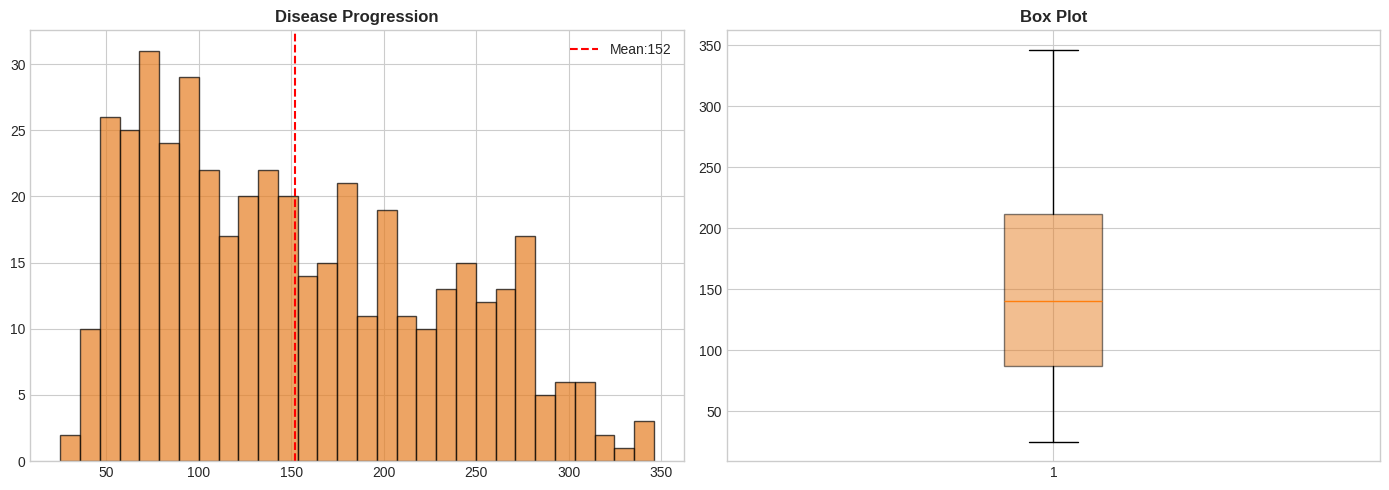

AU: 1.3M+ Australians with diabetes. NDSS supports disease management.


In [2]:
tc='target'
print(df[tc].describe())
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df[tc],bins=30,color='#e67e22',edgecolor='black',alpha=0.7)
axes[0].set_title('Disease Progression',fontweight='bold')
axes[0].axvline(df[tc].mean(),color='red',ls='--',label=f'Mean:{df[tc].mean():.0f}')
axes[0].legend()
axes[1].boxplot(df[tc],patch_artist=True,boxprops=dict(facecolor='#e67e22',alpha=0.5))
axes[1].set_title('Box Plot',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: 1.3M+ Australians with diabetes. NDSS supports disease management.")

## 3. EDA

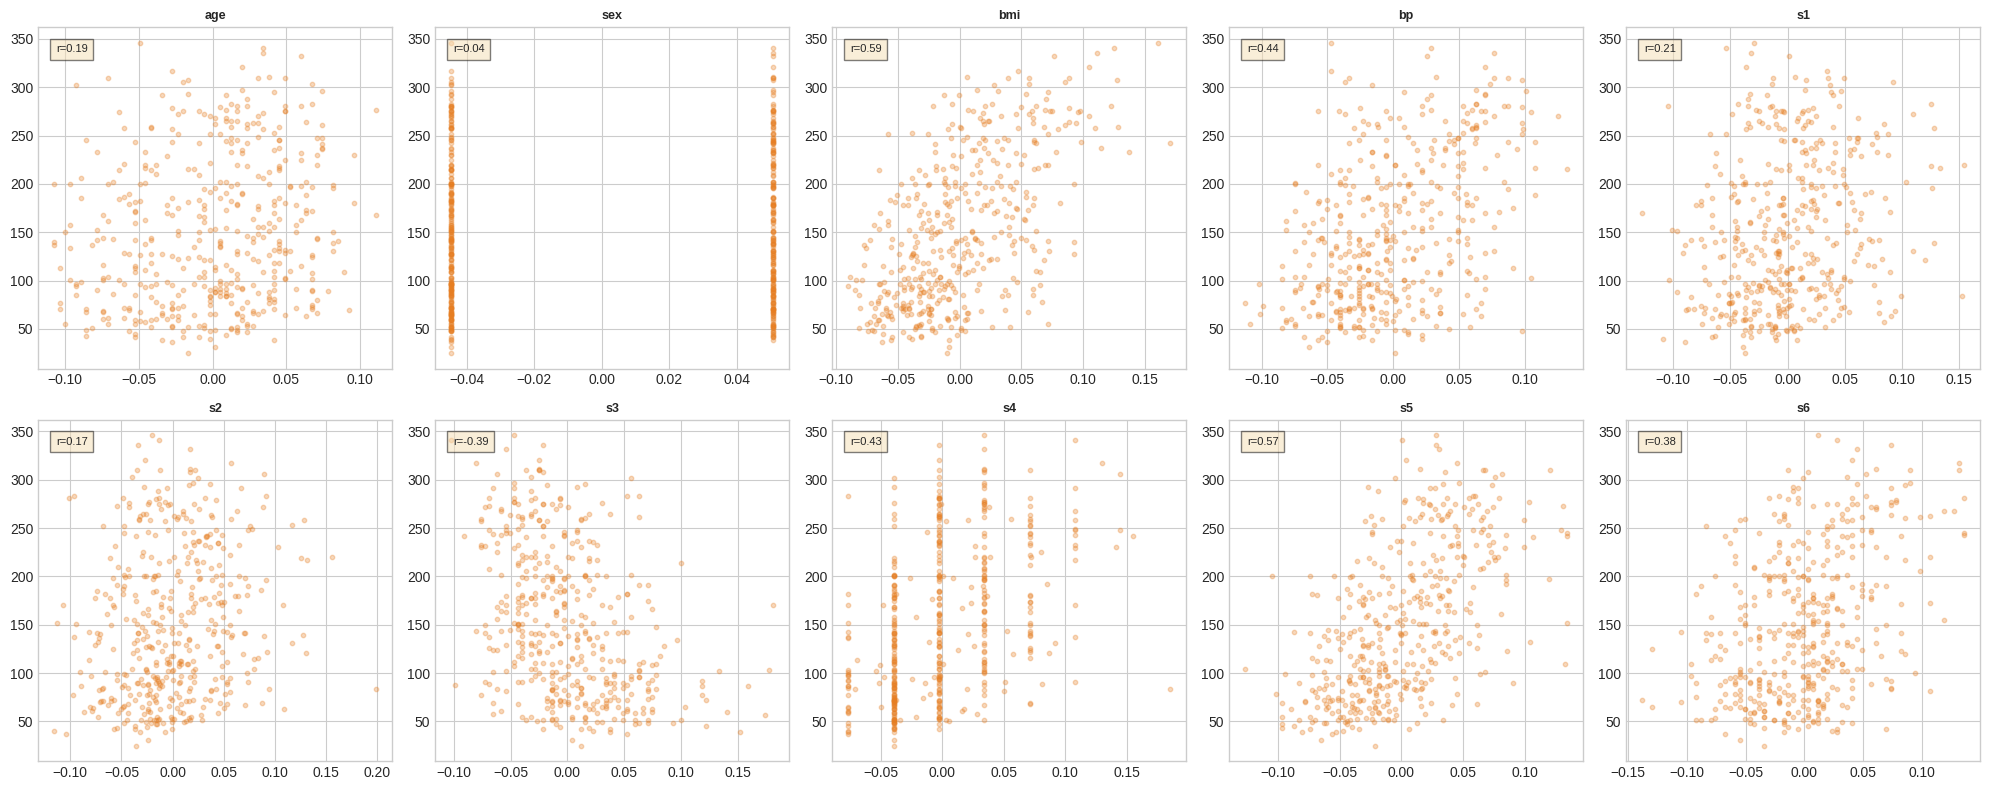

In [3]:
nums=[c2 for c2 in df.columns if c2!=tc]
fig,axes=plt.subplots(2,5,figsize=(20,8));axes=axes.flatten()
for i,col in enumerate(nums):
    axes[i].scatter(df[col],df[tc],alpha=0.3,s=10,color='#e67e22')
    axes[i].set_title(col,fontsize=9,fontweight='bold')
    r=df[[col,tc]].corr().iloc[0,1]
    axes[i].text(0.05,0.95,f'r={r:.2f}',transform=axes[i].transAxes,va='top',fontsize=8,bbox=dict(facecolor='wheat',alpha=0.5))
plt.tight_layout();plt.savefig('scatter.png',dpi=150);plt.show()

## 4-5. Training

In [4]:
X=df[nums];y=df[tc].values
try:
    from xgboost import XGBRegressor
except: XGBRegressor=None
try:
    from lightgbm import LGBMRegressor
except: LGBMRegressor=None
models={'Ridge':Ridge(alpha=1.0),'RF':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBRegressor: models['XGB']=XGBRegressor(n_estimators=100,random_state=42,verbosity=0,n_jobs=-1)
if LGBMRegressor: models['LGBM']=LGBMRegressor(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
kf=KFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fr,fm,f2=[],[],[];fp=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(kf.split(Xa)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        r=np.sqrt(mean_squared_error(y[vi],yp));m3=mean_absolute_error(y[vi],yp);s=r2_score(y[vi],yp)
        fr.append(r);fm.append(m3);f2.append(s);print(f"  Fold{fi+1}: RMSE={r:.1f} MAE={m3:.1f} R2={s:.4f}")
    el=time.time()-t0;results[mn]={'rmse':np.mean(fr),'mae':np.mean(fm),'r2':np.mean(f2),'time':el,'preds':fp}
    print(f"  AVG: RMSE={np.mean(fr):.1f} MAE={np.mean(fm):.1f} R2={np.mean(f2):.4f}")


Ridge
  Fold1: RMSE=56.2 MAE=45.9 R2=0.4454
  Fold2: RMSE=59.7 MAE=50.2 R2=0.3539
  Fold3: RMSE=62.3 MAE=53.5 R2=0.4083
  AVG: RMSE=59.4 MAE=49.9 R2=0.4026

RF
  Fold1: RMSE=55.0 MAE=43.9 R2=0.4681
  Fold2: RMSE=62.6 MAE=50.7 R2=0.2902
  Fold3: RMSE=58.4 MAE=48.1 R2=0.4793
  AVG: RMSE=58.7 MAE=47.6 R2=0.4125

XGB
  Fold1: RMSE=60.4 MAE=48.4 R2=0.3586
  Fold2: RMSE=70.1 MAE=55.4 R2=0.1104
  Fold3: RMSE=64.0 MAE=50.2 R2=0.3750
  AVG: RMSE=64.8 MAE=51.3 R2=0.2813

LGBM
  Fold1: RMSE=58.3 MAE=44.9 R2=0.4029
  Fold2: RMSE=64.0 MAE=50.7 R2=0.2569
  Fold3: RMSE=59.3 MAE=48.4 R2=0.4636
  AVG: RMSE=60.5 MAE=48.0 R2=0.3745


## 6. Comparison

In [5]:
rows=[{'Model':k,'RMSE':f"{v['rmse']:.1f}",'MAE':f"{v['mae']:.1f}",'R2':f"{v['r2']:.4f}",'s':v['r2']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','RMSE','MAE','R2']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
Model RMSE  MAE     R2
   RF 58.7 47.6 0.4125
Ridge 59.4 49.9 0.4026
 LGBM 60.5 48.0 0.3745
  XGB 64.8 51.3 0.2813

Best: RF


## 7. Residuals

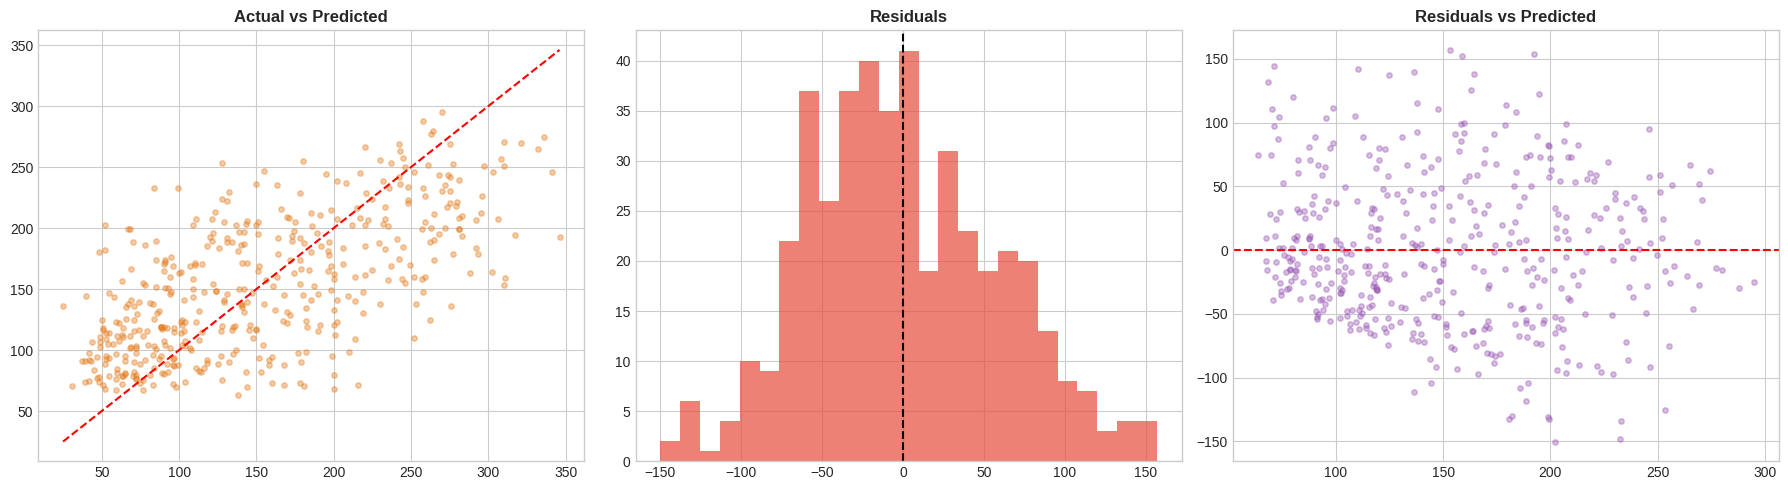

In [6]:
bp=results[best]['preds'];res=y-bp
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].scatter(y,bp,alpha=0.4,s=15,color='#e67e22');lm=[min(y.min(),bp.min()),max(y.max(),bp.max())]
axes[0].plot(lm,lm,'r--');axes[0].set_title('Actual vs Predicted',fontweight='bold')
axes[1].hist(res,bins=25,color='#e74c3c',alpha=0.7);axes[1].axvline(0,color='k',ls='--');axes[1].set_title('Residuals',fontweight='bold')
axes[2].scatter(bp,res,alpha=0.4,s=15,color='#9b59b6');axes[2].axhline(0,color='r',ls='--');axes[2].set_title('Residuals vs Predicted',fontweight='bold')
plt.tight_layout();plt.savefig('resid.png',dpi=150);plt.show()

## 8. Importance & Deployment

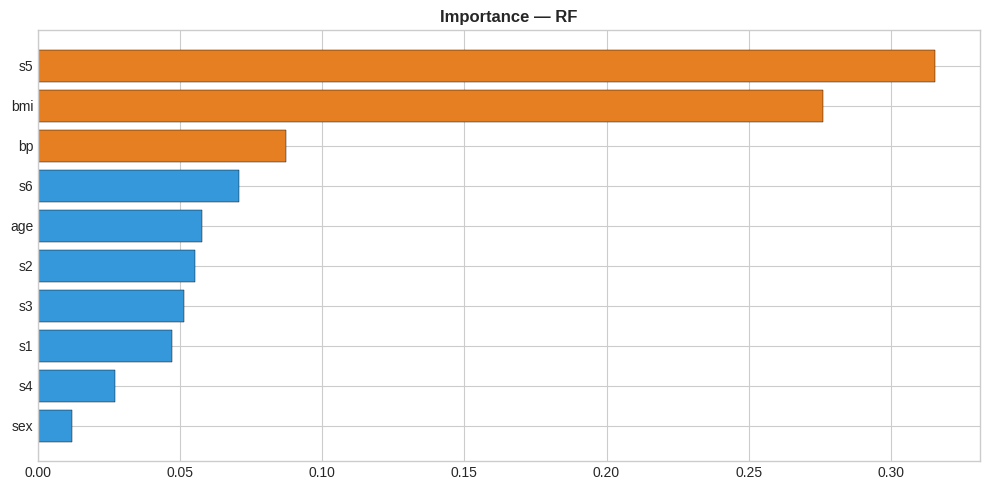

DEPLOYMENT READINESS
  Model: RF  R2: 0.4125  MAE: 47.6
  Feats: 10  Rows: 442
  [pass] R2>0.30
  [pass] CV
  APPROVED

Architecture: NDSS registry, pathology HbA1c -> Fabric -> GP decision support


In [7]:
tm={k:v for k,v in models.items() if k!='Ridge'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['r2']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,5))
    ax.barh(fi['Feature'],fi['Imp'],color=['#e67e22' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}  R2: {br['r2']:.4f}  MAE: {br['mae']:.1f}")
print(f"  Feats: {X.shape[1]}  Rows: {len(y):,}")
checks={'R2>0.30':br['r2']>0.30,'CV':True}
ap=all(checks.values())
for k,v in checks.items(): print(f"  [{'pass' if v else 'FAIL':4s}] {k}")
print("  APPROVED" if ap else "  FAILED")
print("\nArchitecture: NDSS registry, pathology HbA1c -> Fabric -> GP decision support")